In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
data=np.load("20230525HeatBudget&HeatWave.npz")

In [3]:
import xarray as xr 

In [4]:
data.files

['mltt', 'Q', 'hadv']

In [5]:
mltt=np.array(data['mltt'])

In [6]:
Q=np.array(data['Q'])
hadv=np.array(data['hadv'])

In [7]:
times=pd.date_range('1993-01-01','2022-12-31',freq='1D')
times=times[:-1]

In [8]:
times.year

Int64Index([1993, 1993, 1993, 1993, 1993, 1993, 1993, 1993, 1993, 1993,
            ...
            2022, 2022, 2022, 2022, 2022, 2022, 2022, 2022, 2022, 2022],
           dtype='int64', length=10956)

In [9]:
lon=np.arange(150,250.25,0.25)
lat=np.arange(20,60.25,0.25)

In [10]:
def yermon(date):
    year = np.array(date.year,dtype=float)
    month = np.array(date.month,dtype=float)
    month[month<6]=0.
    month[month>=6]=0.5
    return(month+year)
def yearis(dat):
    elyear=[1951.5, 1952.0,1953.5, 1954.0,1957.5, 1958.0,1958.5, 1959.0,1963.5, 
            1964.0,1965.5, 1966.0,1968.5, 1969.0,1969.5, 1970.0,1972.5, 1973.0,
            1976.5, 1977.0,1977.5, 1978.0,1979.5, 1980.0,1982.5, 1983.0,1986.5, 
            1987.0,1987.5, 1988.0,1991.5, 1992.0,1994.5, 1995.0,1997.5,1998.0,
            2002.5,2003.0,2004.5,2005.0,2006.5,2007.0,2009.5,2010.0,2014.5,2015.0,
            2015.5,2016.0,2018.5,2019.0]
    layear=[1954.5, 1955.0,1955.5, 1956.0,1964.5, 1965.0,1970.5, 1971.0,1971.5, 
            1972.0,1973.5, 1974.0,1974.5, 1975.0,1975.5, 1976.0,1983.5, 1984.0,
            1984.5, 1985.0,1988.5, 1989.0,1995.5, 1996.0,1998.5, 1999.0,1999.5, 
            2000.0,2000.5, 2001.0,2005.5, 2006.0,2007.5, 2008.0,2008.5, 2009.0,
            2010.5, 2011.0,2011.5, 2012.0,2016.5, 2017.0,2017.5, 2018.0,2020.5, 
            2021.0,2021.5, 2022.0]
    date=yermon(dat)
    if date in elyear:
        return 'el'
    elif date in layear:
        return 'la'
    else:
        return 'an'

In [11]:
yeartype=list(map(yearis,times))

In [12]:
#计算气候态

In [13]:
mltt=xr.DataArray(mltt,coords=[times,lat,lon],dims=['time','lat','lon'])

In [14]:
mltt=mltt.loc[:,35:50,195:230]

In [15]:
mltt.shape

(10956, 61, 141)

In [ ]:
mltt.shape

(10956, 61, 141)

In [16]:
mltt_la=mltt.loc['2017-06':'2018-05',:,:]

In [17]:
Q=xr.DataArray(Q[:10956,:,:],coords=[times,lat,lon],dims=['time','lat','lon'])

In [18]:
Q=Q.loc[:,35:50,195:230]

In [19]:
Q

<xarray.DataArray (time: 10956, lat: 61, lon: 141)>
array([[[ 3.76109656e-02,  3.66863581e-02,  3.65871334e-02, ...,
         -1.36504200e-02, -1.18696672e-02, -1.14440569e-02],
        [ 3.63736037e-02,  3.61341970e-02,  3.42603205e-02, ...,
         -1.44988069e-02, -1.34760819e-02, -1.39102281e-02],
        [ 3.54842159e-02,  3.45047957e-02,  3.29958360e-02, ...,
         -1.82696024e-02, -1.69923542e-02, -1.62660266e-02],
        ...,
        [-2.05392059e-02,  1.29739734e-03,  1.11214848e-02, ...,
          1.84252675e-02,  1.84102521e-02,  1.30162707e-02],
        [-1.62183800e-02, -2.99961992e-03, -2.78771890e-04, ...,
          1.63310922e-02,  1.59920220e-02,  1.40885398e-02],
        [-1.15601218e-02, -1.07667931e-02, -9.05302653e-03, ...,
          1.52430666e-02,  1.64726706e-02,  1.64071345e-02]],

       [[ 3.73951355e-02,  3.67592999e-02,  3.61922414e-02, ...,
         -2.83990629e-02, -2.51596759e-02, -2.74290544e-02],
        [ 3.65724333e-02,  3.64322106e-02,  3.41556336e-02, ...,
         -3.98397577e-02, -3.45641721e-02, -3.92278538e-02],
        [ 3.45933817e-02,  3.35102819e-02,  3.16899293e-02, ...,
         -3.36666017e-02, -3.79323677e-02, -4.28351995e-02],
...
        [-4.04080559e-03, -3.21529290e-03,  1.41719865e-03, ...,
          1.45674607e-02,  1.87874937e-02,  2.24395198e-02],
        [ 7.32396645e-03,  1.16392254e-02,  1.62338725e-02, ...,
          1.72129324e-02,  2.01607133e-02,  2.30319784e-02],
        [ 1.96419369e-02,  2.64758585e-02,  2.75783305e-02, ...,
          1.83025458e-02,  1.68138388e-02,  1.95274658e-02]],

       [[-5.96032979e-02, -5.73615631e-02, -5.58357513e-02, ...,
          2.12863372e-02,  2.03703965e-02,  1.87189823e-02],
        [-5.89714495e-02, -5.80923986e-02, -5.55765488e-02, ...,
          2.31223876e-02,  2.19695280e-02,  2.19062376e-02],
        [-5.47013779e-02, -5.67754935e-02, -5.54068248e-02, ...,
          2.40609483e-02,  2.40864922e-02,  2.52712949e-02],
        ...,
        [ 2.47187015e-03,  2.45842468e-03,  2.39515721e-03, ...,
          2.45033957e-02,  2.47634797e-02,  2.51004579e-02],
        [ 1.57316895e-03,  7.94671604e-04,  4.16829949e-03, ...,
          2.52121109e-02,  2.45758208e-02,  2.36487999e-02],
        [-5.44856993e-03,  3.53607515e-03,  4.53731164e-03, ...,
          2.48442813e-02,  2.08638590e-02,  1.86827274e-02]]])
Coordinates:
  * time     (time) datetime64[ns] 1993-01-01 1993-01-02 ... 2022-12-30
  * lat      (lat) float64 35.0 35.25 35.5 35.75 36.0 ... 49.25 49.5 49.75 50.0
  * lon      (lon) float64 195.0 195.2 195.5 195.8 ... 229.2 229.5 229.8 230.0

In [20]:
hadv=xr.DataArray(hadv[:10956,:,:],coords=[times,lat[:160],lon[:400]],dims=['time','lat','lon'])

In [21]:
hadv=hadv.loc[:,35:50,195:230]

In [22]:
#分年份

In [23]:
ovmix=mltt-Q-hadv

In [24]:
hadv_la=hadv.loc['2017-06':'2018-05',:,:]
ovmix_la=ovmix.loc['2017-06':'2018-05',:,:]
Q_la=Q.loc['2017-06':'2018-05',:,:]

In [25]:
Q_la

<xarray.DataArray (time: 365, lat: 61, lon: 141)>
array([[[-4.90782250e-02, -5.90049226e-02, -6.43322196e-02, ...,
         -4.98918199e-02, -6.41175198e-02, -6.95532369e-02],
        [-4.35260075e-02, -5.74274280e-02, -6.78386511e-02, ...,
         -6.99602163e-02, -8.46947653e-02, -8.13155372e-02],
        [-6.90947959e-02, -6.92254997e-02, -7.56632967e-02, ...,
         -7.82189254e-02, -7.96405412e-02, -1.06919037e-01],
        ...,
        [ 2.93185269e-02,  6.59303783e-02,  1.06995787e-01, ...,
          4.16870542e-01,  4.00940296e-01,  3.70787737e-01],
        [ 2.50365082e-02,  4.29731420e-02,  5.34594744e-02, ...,
          4.22383026e-01,  4.05760456e-01,  3.80044305e-01],
        [ 5.75892285e-02,  4.54842641e-02,  1.52861648e-02, ...,
          4.05698164e-01,  3.93481627e-01,  3.76954775e-01]],

       [[-5.87408307e-02, -6.04971507e-02, -6.19771069e-02, ...,
          1.10692476e-01,  7.68266573e-02,  5.64452597e-02],
        [-4.59022897e-02, -4.77629233e-02, -5.28833130e-02, ...,
          7.53712356e-02,  4.99010738e-02,  3.96387304e-02],
        [-6.06682610e-02, -5.64324506e-02, -5.40912789e-02, ...,
          4.74225538e-02,  2.66835836e-02,  8.12840029e-03],
...
        [ 2.53024621e-02,  1.46369056e-02,  5.12264094e-03, ...,
         -2.11882674e-01, -2.23743332e-01, -2.14691805e-01],
        [-4.32676428e-03, -1.03480404e-02, -4.48886270e-02, ...,
         -2.02120287e-01, -2.26091290e-01, -2.37042575e-01],
        [ 1.01330216e-02,  3.59772552e-02,  3.25589280e-02, ...,
         -2.12913622e-01, -2.32238345e-01, -2.23176943e-01]],

       [[-9.43663021e-02, -4.94721586e-02, -4.25703489e-02, ...,
          4.18517734e-02,  1.03449439e-01,  6.34616352e-02],
        [-1.10810307e-01, -7.46217869e-02, -7.04629671e-02, ...,
         -1.43034063e-02,  3.75808947e-02,  1.90333431e-02],
        [-1.12662680e-01, -1.08361095e-01, -9.64953759e-02, ...,
          1.49155218e-02, -3.57235767e-04, -1.61263671e-02],
        ...,
        [-3.62010556e-02, -4.73005196e-02, -5.79478344e-02, ...,
         -2.06739676e-01, -2.19085851e-01, -2.17294996e-01],
        [-5.83081168e-02, -9.11260954e-02, -1.13884191e-01, ...,
         -2.05216985e-01, -2.16259419e-01, -2.10731938e-01],
        [-5.76045231e-02, -3.55005852e-02, -4.07228087e-02, ...,
         -2.31163951e-01, -2.24875818e-01, -1.96288985e-01]]])
Coordinates:
  * time     (time) datetime64[ns] 2017-06-01 2017-06-02 ... 2018-05-31
  * lat      (lat) float64 35.0 35.25 35.5 35.75 36.0 ... 49.25 49.5 49.75 50.0
  * lon      (lon) float64 195.0 195.2 195.5 195.8 ... 229.2 229.5 229.8 230.0

In [26]:
#筛选elnino/lanina/neutral年

In [27]:
Q_la_monthly=Q_la.groupby('time.season')

In [28]:
hadv_la_monthly=hadv_la.groupby('time.season')
mltt_la_monthly=mltt_la.groupby('time.season')
ovmix_la_monthly=ovmix_la.groupby('time.season')

In [29]:
hadv_la_monthly

DataArrayGroupBy, grouped over 'season'
4 groups with labels 'DJF', 'JJA', 'MAM', 'SON'.

In [30]:
hadv_la_monthly['JJA']

<xarray.DataArray (time: 92, lat: 61, lon: 141)>
array([[[-0.02178038,  0.00957608,  0.1376072 , ...,  0.03614765,
         -0.0993557 ,  0.06959533],
        [-0.04476045, -0.01673845,  0.07562502, ...,  0.13084232,
          0.11816013,  0.00061282],
        [ 0.08176215, -0.09559559,  0.01133125, ...,  0.0327315 ,
          0.02135029, -0.13134553],
        ...,
        [-0.03139883, -0.02579815, -0.01862168, ...,  0.05899981,
         -0.02935277, -0.0281291 ],
        [-0.00479272,  0.00050545,  0.03199008, ..., -0.05646045,
         -0.02247312, -0.04163083],
        [-0.03139827,  0.01564524, -0.03970721, ...,  0.00542181,
         -0.05068198, -0.11623025]],

       [[-0.01620646,  0.01904568,  0.11486574, ...,  0.05022336,
         -0.04649918, -0.06001492],
        [-0.03275817, -0.00056181,  0.09984528, ...,  0.13852331,
          0.14940132,  0.00831359],
        [ 0.10065634, -0.09565433,  0.02556847, ..., -0.01467758,
         -0.02168374, -0.05595083],
...
        [-0.00961915, -0.00042313, -0.00930678, ...,  0.06494538,
          0.08892909,  0.02758524],
        [-0.01098032,  0.00604481,  0.00547781, ...,  0.10588404,
          0.00877845,  0.00919955],
        [ 0.00630969,  0.02504654,  0.00724539, ...,  0.13877789,
          0.05312831, -0.05601574]],

       [[ 0.00289071,  0.00249633,  0.06827081, ...,  0.03213302,
          0.01474047,  0.00999394],
        [ 0.00054403,  0.09303514, -0.00709065, ...,  0.02187744,
          0.0265199 ,  0.02435983],
        [ 0.18720867, -0.12200606, -0.08559024, ..., -0.02100236,
          0.01552356,  0.04747882],
        ...,
        [-0.00741407,  0.00923716,  0.00867622, ...,  0.01740733,
          0.04776385,  0.01003877],
        [ 0.01223042,  0.02168843,  0.01939225, ...,  0.10978003,
          0.00484476, -0.00711874],
        [ 0.01430162,  0.0364605 ,  0.01596292, ...,  0.11955449,
          0.07288018, -0.0776566 ]]])
Coordinates:
  * time     (time) datetime64[ns] 2017-06-01 2017-06-02 ... 2017-08-31
  * lat      (lat) float64 35.0 35.25 35.5 35.75 36.0 ... 49.25 49.5 49.75 50.0
  * lon      (lon) float64 195.0 195.2 195.5 195.8 ... 229.2 229.5 229.8 230.0

In [33]:
Q_la_monthly

DataArrayGroupBy, grouped over 'season'
4 groups with labels 'DJF', 'JJA', 'MAM', 'SON'.

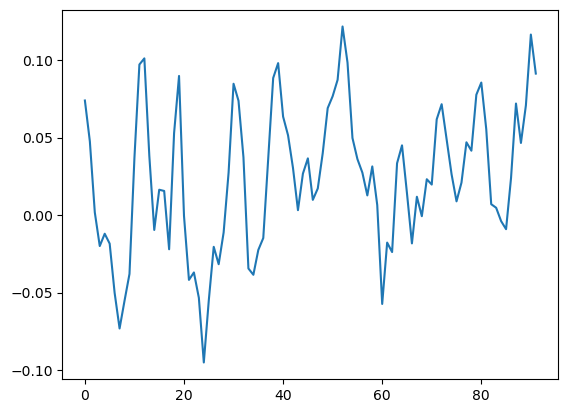

In [34]:
plt.plot(np.nanmean(np.nanmean(Q_la_monthly['JJA'],axis=1),axis=1))

Text(0.5, 1.0, 'Lanina year summer heat budget')

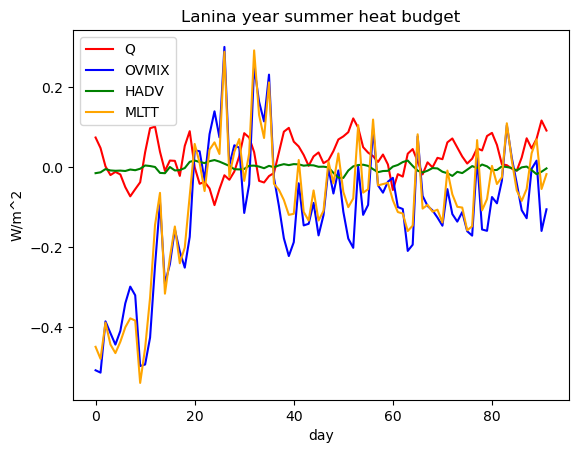

In [38]:
plt.plot(np.nanmean(np.nanmean(Q_la_monthly['JJA'],axis=1),axis=1),color='red',label='Q')
plt.plot(np.nanmean(np.nanmean(ovmix_la_monthly['JJA'],axis=1),axis=1),color='blue',label='OVMIX')
plt.plot(np.nanmean(np.nanmean(hadv_la_monthly['JJA'],axis=1),axis=1),color='green',label='HADV')
plt.plot(np.nanmean(np.nanmean(mltt_la_monthly['JJA'],axis=1),axis=1),color='orange',label='MLTT')
plt.legend()
plt.xlabel('day')
plt.ylabel('W/m^2')
plt.title('Lanina year summer heat budget')

In [ ]:
plt.plot(ovmix_la_monthly.mean(axis=(1,2)))
plt.plot(hadv_la_monthly.mean(axis=(1,2)))
plt.plot(mltt_la_monthly.mean(axis=(1,2)))